In [ ]:
from model_builder import ModelBuilder
from model_builder_keras import KerasModelBuilder

from preprocessing import Preprocessor
from plotting_other import Plotter
from plotting import plot_dataset
#from shapley import ProcessAttributor
from shapley_improved import ProcessAttributorSHAP
from shapley_improved_other import ProcessAttributorSHAPMLP

from universal_filtering import CustomSpearmanFilter
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
#from sklearn.linear_model import Ridge
#from sklearn.linear_model import Lasso
from sklearn.base import BaseEstimator, RegressorMixin
import numpy as np

# Basic Deep Learning with Sklearn MLP
from sklearn.neural_network import MLPRegressor
from sklearn.inspection import permutation_importance

# Deep Learning with Keras Tensorflow
#import keras
from keras import layers, optimizers, callbacks, Sequential
#https://ipython.org/ipython-doc/3/config/extensions/autoreload.html
%load_ext autoreload
%autoreload 2

I0000 00:00:1784817360.125606 1377326 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784817360.166391 1377326 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784817361.430471 1377326 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
train_mixed_unseen_type = [
    pd.read_parquet("../../../../ProcessEnergyAccounting/runs/nfcore-20260704T110043Z/datasets/chipseq_2_0607.parquet"),
    pd.read_parquet("../../../../ProcessEnergyAccounting/runs/nfcore-20260701T114734Z/datasets/rnaseq_1_02027.parquet"),
    pd.read_parquet("../../../../ProcessEnergyAccounting/runs/nfcore-20260701T215234Z/datasets/sarek_1_0207.parquet"),
    pd.read_parquet("../../../../ProcessEnergyAccounting/runs/nfcore-20260704T093159Z/datasets/ampliseq_2_0607.parquet")

]
test_mixed_unseen_type = pd.read_parquet("../../../../ProcessEnergyAccounting/runs/nfcore-20260704T093159Z/datasets/ampliseq_2_0607.parquet")


In [3]:
training_data = pd.concat(train_mixed_unseen_type, ignore_index=True)
training_data = training_data
test_data = test_mixed_unseen_type
PNG_NAME = "mlp_pred_ampl"

features = [
    "delta_cpu_ns",
    "delta_io_bytes",
    "delta_net_send_bytes",
    "context_switches",
    "syscall_count",
    "delta_rss_memory",
    "delta_cpu_time_psutil",
    "delta_cpu_time_proc",
    "syscall_class_file",
    "syscall_class_network",
    "syscall_class_memory",
    "syscall_class_process",
    "syscall_class_other",
    "syscall_class_sched",
    "syscall_class_signal",
    "syscall_class_time",
    "delta_cycles",
    "delta_cache_misses",
    "delta_instructions",
    "delta_branch_instructions",
]


In [4]:
preprocessor_train = Preprocessor(training_data, features)
X_train_FULL, y_train, t_train, _ = preprocessor_train.preprocess_no_split()

Dropped 0 timestamps.


In [5]:
#plot_dataset(t_train, y_train, "multi_training")


In [6]:
#build_model = ExplainableBoostingRegressor( interactions=2, max_rounds=2000, n_jobs=-1, random_state=42)
model = RandomForestRegressor(n_estimators=100,  n_jobs=-1, random_state=42)
#build_model = MLPRegressor(activation="relu", solver="adam", random_state=42)



In [7]:
#These thresholds could be fine tuned
automatic_feature_selection = Pipeline(steps=[
    ('variance', VarianceThreshold(threshold=0.01)), #explain this

    ('decorrelate', CustomSpearmanFilter(threshold=0.80)),
    ('scaler', StandardScaler()),
    ('select_features', SelectFromModel(model, threshold='0.5*median'))
])

automatic_feature_selection.set_output(transform="pandas")
automatic_feature_selection.fit_transform(X_train_FULL, y_train)
good_features = automatic_feature_selection.get_feature_names_out().tolist()
X_train = X_train_FULL[good_features]
print("Selected columns:")
print(good_features)


#plot_dataset(t_train, y_train, "multi_training")

Selected columns:
['delta_cpu_ns', 'delta_io_bytes', 'delta_net_send_bytes', 'context_switches', 'syscall_count', 'delta_rss_memory', 'delta_cpu_time_proc', 'syscall_class_file', 'syscall_class_network', 'syscall_class_memory', 'syscall_class_process', 'syscall_class_other']


In [8]:
preprocessor_test = Preprocessor(test_data, good_features)
X_test, y_test, t_test , X_test_unaggregated = preprocessor_test.preprocess_no_split()

#plot_dataset(t_test, y_test, "multi_testing")

Dropped 0 timestamps.


In [9]:
X_train

,delta_cpu_ns,delta_io_bytes,delta_net_send_bytes,context_switches,syscall_count,delta_rss_memory,delta_cpu_time_proc,syscall_class_file,syscall_class_network,syscall_class_memory,syscall_class_process,syscall_class_other
_time,,,,,,,,,,,,
2026-07-01 11:47:37+00:00,193077878.0,233472.0,420697.0,1288.0,30753.0,0.0,1.770000e+09,7880.0,194.0,1.0,25.0,22135.0
2026-07-01 11:47:39+00:00,188727201.0,163840.0,416306.0,1230.0,29934.0,0.0,1.900000e+09,8054.0,186.0,0.0,1.0,21651.0
2026-07-01 11:47:41+00:00,194398251.0,405504.0,456430.0,1254.0,29937.0,0.0,1.770000e+09,8053.0,189.0,1.0,0.0,21647.0
2026-07-01 11:47:43+00:00,203899884.0,266240.0,455721.0,1218.0,30627.0,0.0,1.740000e+09,8416.0,194.0,1.0,1.0,21998.0
2026-07-01 11:47:45+00:00,196072439.0,167936.0,452078.0,1178.0,29794.0,0.0,1.760000e+09,8029.0,184.0,1.0,1.0,21543.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-04 20:57:13+00:00,276691950.0,253952.0,878996.0,1146.0,43386.0,0.0,3.080000e+09,11021.0,199.0,0.0,1.0,32117.0
2026-07-04 20:57:15+00:00,290804470.0,307200.0,883490.0,1282.0,42769.0,0.0,4.070000e+09,10648.0,186.0,0.0,1.0,31898.0
2026-07-04 20:57:17+00:00,268518458.0,258048.0,883829.0,1104.0,42744.0,0.0,2.940000e+09,10634.0,199.0,0.0,1.0,31868.0


In [10]:
plot_dataset(t_test, y_test, "multi_testing")

### Sklearn MLP

In [11]:
build_model_mlp = MLPRegressor(hidden_layer_sizes=(128,32,16),
                    activation='relu',
                    solver='adam',
                    learning_rate_init=0.0001,
                    max_iter=500,
                    #alpha = 0.0000675,
                    batch_size=64,
                    early_stopping=True,    # Crucial for time-series stability
                    #validation_fraction=0.1,
                    random_state=42)

In [12]:
builder = ModelBuilder(X_train, X_test, y_train, y_test, build_model_mlp, StandardScaler())
y_pred, learned_idle_power = builder.run_and_save_model()


  R² Score:  0.8782
  MAE:       5.05 Ws (2.65% of mean)
----------------------------------
The model's learned baseline idle interval energy is: 119.97 Ws
----------------------------------
/n


In [13]:
plotter = Plotter(y_pred,y_test, t_test,"mlp")#, window_start =50, window_end=200)
plotter.plot_and_save("", PNG_NAME)

In [14]:
#check if we ann pass this differently
#attributor = ProcessAttributorSHAPMLP( builder.X_test_scaled, builder.model, builder.scaler)
#attributor.attribute(X_test_unaggregated,good_features,t_test.values, "mlp_graphs_")

### Deep Learning with Keras

Build the 1D-CNN in Keras (Tutorials)

- https://keras.io/guides/sequential_model/
- https://keras.io/examples/timeseries/timeseries_classification_from_scratch/
- https://www.tensorflow.org/tutorials/structured_data/time_series#recurrent_neural_network
- https://keras.io/examples/timeseries/timeseries_classification_from_scratch/



In [15]:
num_features = len(good_features)

In [16]:
# Models used
# Convolutional Neural Network (1D)
cnn_model = Sequential([

    layers.Input(shape=(num_features, 1)), # (num_features, sequence_length) #Only current value
    layers.Conv1D(32, kernel_size=num_features, padding='same', activation="relu"),
    layers.BatchNormalization(),

    layers.Conv1D(32, kernel_size=num_features, padding='same', activation="relu"),
    layers.BatchNormalization(),

    #layers.Conv1D(32, kernel_size=num_features, padding='same', activation="relu"),
    #layers.BatchNormalization(),
    
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
    
])

# Feed Forward Neural Network
ffnn_model = Sequential([
    layers.Input(shape=(num_features, 1)), # (num_features, sequence_length) #Only current value
    layers.Flatten(),
    #layers.GlobalAveragePooling1D(),
    #layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    #layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
    
])

# LSTM Model
lstm_model = Sequential([
    layers.Input(shape=(num_features, 1)), # (num_features, sequence_length) #Only current value
    layers.BatchNormalization(),
    layers.LSTM(64, return_sequences=True),
    layers.LSTM(64, return_sequences=True),
    layers.Flatten(),
    #layers.GlobalAveragePooling1D(),
    #layers.Dropout(0.2),
    #layers.Dense(32, activation='relu'),
    layers.Dense(1)
    
])

In [17]:
builder_lstm = KerasModelBuilder(X_train, X_test, y_train, y_test, lstm_model, StandardScaler())
y_pred_lstm, learned_idle_power = builder_lstm.run_and_save_model()

Epoch 1/30
492/492 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 8673.1328 - mae: 66.4860 - val_loss: 362.6549 - val_mae: 14.8274 - learning_rate: 0.0010
Epoch 2/30
492/492 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 254.4376 - mae: 11.4440 - val_loss: 306.8332 - val_mae: 13.8465 - learning_rate: 0.0010
Epoch 3/30
492/492 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 241.3392 - mae: 10.9413 - val_loss: 304.4904 - val_mae: 13.4822 - learning_rate: 0.0010
Epoch 4/30
492/492 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 239.5718 - mae: 10.8165 - val_loss: 304.5312 - val_mae: 13.3051 - learning_rate: 0.0010
Epoch 5/30
492/492 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 235.3067 - mae: 10.6132 - val_loss: 299.6674 - val_mae: 13.2010 - learning_rate: 0.0010
Epoch 6/30
492/492 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 234.9107 - mae: 10.6018 - val_loss: 297.2959 - val_mae: 13.1093 - learning_rate: 0.0010
Epoch 7/30
492/492 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 233.3208 - mae: 10.5214 - val_loss: 299.747

In [18]:
#plotter = Plotter(y_pred=y_pred_lstm,y_test=y_test, t_test= t_test,alg_name="lstm",window_start=150, window_end=200)
plotter = Plotter(y_pred=y_pred_lstm,y_test=y_test, t_test= t_test,alg_name="lstm")
#plotter.plot_only("lstm_")
plotter.plot_and_save("ltsm_")

In [20]:
builder_cnn = KerasModelBuilder(X_train, X_test, y_train, y_test, cnn_model, StandardScaler())
y_pred_cnn, learned_idle_power = builder_cnn.run_and_save_model()

Epoch 1/30
492/492 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 4669.9600 - mae: 35.8736 - val_loss: 2531.3308 - val_mae: 41.2708
Epoch 2/30
492/492 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 156.1600 - mae: 9.2119 - val_loss: 1023.8440 - val_mae: 20.8697
Epoch 3/30
492/492 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 134.6990 - mae: 8.5520 - val_loss: 993.0801 - val_mae: 20.9029
Epoch 4/30
492/492 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 124.6226 - mae: 8.1591 - val_loss: 787.8681 - val_mae: 19.1046
Epoch 5/30
492/492 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 121.8450 - mae: 8.0812 - val_loss: 818.9437 - val_mae: 19.0763
Epoch 6/30
492/492 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 117.3389 - mae: 7.9272 - val_loss: 610.6256 - val_mae: 15.0825
Epoch 7/30
492/492 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 115.2742 - mae: 7.8973 - val_loss: 624.8547 - val_mae: 16.6789
Epoch 8/30
492/492 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 110.9487 - mae: 7.7320 - val_loss: 826.3269 - val_mae: 20.0535
Epoch 9/30
4

In [21]:
plotter = Plotter(y_pred=y_pred_cnn,y_test=y_test, t_test= t_test,alg_name="cnn_1d")
#plotter.plot_only("cnn_1d")
plotter.plot_and_save("cnn_1d_")

In [22]:
#64-16 # Faster other models
#  R² Score:  0.9224
#  MAE:       5.53 Ws (2.75% of mean)
builder_ffnn = KerasModelBuilder(X_train, X_test, y_train, y_test, ffnn_model, StandardScaler())
y_pred_ffnn, learned_idle_power = builder_cnn.run_and_save_model()

Epoch 1/30
492/492 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 93.2377 - mae: 7.0093 - val_loss: 409.5308 - val_mae: 13.8637
Epoch 2/30
492/492 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 92.7425 - mae: 6.9875 - val_loss: 468.8109 - val_mae: 14.4419
Epoch 3/30
492/492 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 92.3114 - mae: 6.9892 - val_loss: 376.6224 - val_mae: 13.4075
Epoch 4/30
492/492 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 91.5063 - mae: 6.9651 - val_loss: 416.8093 - val_mae: 14.2681
Epoch 5/30
492/492 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 91.1398 - mae: 6.9464 - val_loss: 378.8989 - val_mae: 13.2738
Epoch 6/30
492/492 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 90.9654 - mae: 6.9096 - val_loss: 392.6227 - val_mae: 13.7183
Epoch 7/30
492/492 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 90.7299 - mae: 6.9434 - val_loss: 382.6541 - val_mae: 13.4387
Epoch 8/30
492/492 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 89.4295 - mae: 6.8659 - val_loss: 442.1081 - val_mae: 13.8337
Epoch 9/30
492/492 ━━━━━

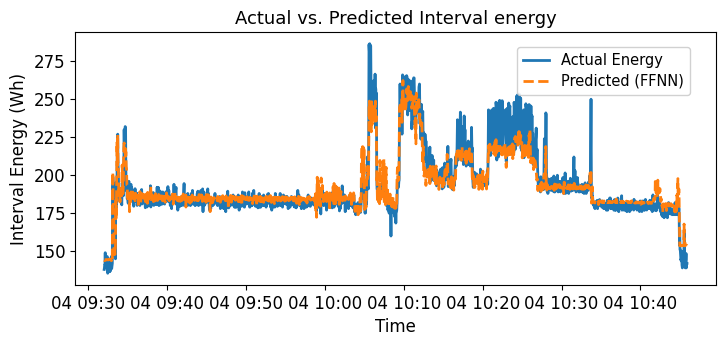

In [23]:
plotter = Plotter(y_pred=y_pred_ffnn,y_test=y_test, t_test= t_test,alg_name="ffnn")
plotter.plot_only("ffnn_")
plotter.plot_and_save("ffnn_")